# 09 - Rotation probe: is the missing feature worth the compute?

<!-- contract -->

| | |
|---|---|
| **Reads** | One month of full-population BTS On-Time Performance, from the raw volume |
| **Writes** | nothing - analysis only, deliberately not in any job |
| **Runtime** | ~2 minutes |
| **Requires** | `tools/fetch_bts.py --years 2023 --months 1`, uploaded to the volume |

`02_eda` put **late aircraft at 38.4% of delay minutes**, the largest single cause, and the
feature that would capture it was never built because `TAIL_NUM` is absent from the Kaggle
sample this project trains on. The README has carried "aircraft rotation chaining would be
the strongest addition available" as an unmeasured claim ever since.

This notebook measures it, on one month, without retraining anything.

## Why a probe rather than a migration

The full BTS table has `TAIL_NUM`. It also has roughly **twelve times** the rows: about 29M
across the four years this project uses, against 2.46M in Gold today. On a platform where
`05_train` already takes ~10 hours, that is not a feature addition, it is a different
project - and it would invalidate every number in the README a second time to find out
whether the idea was any good.

One month costs a 232 MB download and about two minutes of Spark. It cannot tell us what the
model would score. It can tell us whether the signal is there at all, which is the only thing
worth knowing before spending the compute.

## What is being measured

**Scheduled turnaround** is the gap between the previous leg's scheduled arrival and this
leg's scheduled departure, for the same airframe. It is the honest pre-departure version of
the late-aircraft cause: a 35-minute turn has no slack to absorb an inbound delay and a
three-hour turn absorbs it completely. Critically it is **derived from the schedule alone**,
so it is knowable days ahead and carries no leakage - unlike the inbound aircraft's *actual*
arrival delay, which is not available at pre-departure prediction time and would be
train/serve skew of exactly the kind this project has already been bitten by.

**Legs so far today** is the aircraft's position in its own day. Gold currently approximates
this with `dep_sequence_in_day`, a *carrier*-level ordinal, because the real one needs a tail
number. Section 3 checks whether the proxy was any good.

**Congestion counts** are the second thing the sample broke. Counting co-occurring flights in
a ~10% sample counts sampled flights: `sched_deps_origin_hour` had a mean of 3.3 where a hub
runs 50-80, which is the entire reason the share features exist. Section 4 measures the real
number.

In [0]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from src import config, plotting as P

dbutils.widgets.text("BTS_CSV", f"{config.RAW_VOLUME}/bts/bts_2023_01.csv")
BTS_CSV = dbutils.widgets.get("BTS_CSV").strip()

print(f"Reading {BTS_CSV}")
print("If this path does not exist:")
print("  python tools/fetch_bts.py --years 2023 --months 1 --out data/bts")
print(f"  then upload the CSV to {config.RAW_VOLUME}/bts/")

Reading /Volumes/workspace/flights/raw/bts/bts_2023_01.csv
If this path does not exist:
  python tools/fetch_bts.py --years 2023 --months 1 --out data/bts
  then upload the CSV to /Volumes/workspace/flights/raw/bts/


## 1. Load, and label

Cancelled and diverted flights have no arrival delay, so they cannot carry the label. They are
excluded here and counted, rather than filled with a zero that would read as "on time".

The label is the same one Silver uses - arrival 15 minutes or more behind schedule, the US DOT
rule - so the rates below are comparable with every other figure in this project.

In [0]:
raw = spark.read.option("header", True).option("inferSchema", True).csv(BTS_CSV)

print(f"{raw.count():,} rows, {len(raw.columns)} columns in the source")

flights = (
    raw
    .select(
        F.to_date("FlightDate").alias("flight_date"),
        F.col("Tail_Number").alias("tail"),
        F.col("Reporting_Airline").alias("carrier"),
        F.col("Origin").alias("origin"),
        F.col("Dest").alias("dest"),
        F.col("CRSDepTime").cast("int").alias("crs_dep"),
        F.col("CRSArrTime").cast("int").alias("crs_arr"),
        F.col("DepDelay").cast("double").alias("dep_delay"),
        F.col("ArrDelay").cast("double").alias("arr_delay"),
        F.col("Cancelled").cast("double").alias("cancelled"),
        F.col("Diverted").cast("double").alias("diverted"),
    )
    .filter((F.col("cancelled") == 0) & (F.col("diverted") == 0))
    .filter(F.col("arr_delay").isNotNull())
    .withColumn("delayed", (F.col("arr_delay") >= 15).cast("int"))
)

n = flights.count()
base_rate = flights.agg(F.avg("delayed")).first()[0]
print(f"{n:,} completed flights with a known arrival delay")
print(f"Base delay rate: {base_rate:.2%}")

# A tail number is the join key for everything below. Blank ones cannot be chained.
missing_tail = flights.filter(
    F.col("tail").isNull() | (F.trim(F.col("tail")) == "")
).count()
print(f"Rows with no tail number: {missing_tail:,} ({missing_tail / n:.2%}) - excluded "
      f"from the rotation sections")

538,837 rows, 110 columns in the source
527,197 completed flights with a known arrival delay
Base delay rate: 22.14%
Rows with no tail number: 0 (0.00%) - excluded from the rotation sections


## 2. Scheduled turnaround

The aircraft's legs are ordered within a day and each leg is paired with the one before it.

**One detail makes this correct without any timezone arithmetic.** The previous leg *arrives
at* the airport this leg *departs from*, so its `CRSArrTime` and this leg's `CRSDepTime` are
both local clocks at the same airport, and subtracting them is meaningful. Converting either
to UTC first would be the same mistake this project already made once, when a UTC projection
shifted every flight along the hour-of-day risk curve.

Two guards. A pairing where the previous leg's destination is not this leg's origin is not a
turnaround - the airframe was repositioned, or the month boundary cut the chain - so it is
dropped. And a negative gap means the pair straddles midnight, which is a rollover rather than
a time machine.

In [0]:
legs = Window.partitionBy("tail", "flight_date").orderBy("crs_dep")


def hhmm_to_minutes(column):
    """HHMM integer -> minutes past midnight. 2400 is midnight, not hour 24."""
    hhmm = F.col(column) % 2400
    return (F.floor(hhmm / 100) * 60 + (hhmm % 100)).cast("int")


chained = (
    flights
    .filter(F.col("tail").isNotNull() & (F.trim(F.col("tail")) != ""))
    .withColumn("leg_number", F.row_number().over(legs))
    .withColumn("legs_today", F.count("*").over(Window.partitionBy("tail", "flight_date")))
    .withColumn("prev_dest", F.lag("dest").over(legs))
    .withColumn("prev_arr", F.lag("crs_arr").over(legs))
    .withColumn("prev_arr_delay", F.lag("arr_delay").over(legs))
    .filter(F.col("prev_arr").isNotNull())
)

broken = chained.filter(F.col("prev_dest") != F.col("origin")).count()
chained = chained.filter(F.col("prev_dest") == F.col("origin"))

turnaround = (
    chained
    .withColumn("_gap", hhmm_to_minutes("crs_dep") - hhmm_to_minutes("prev_arr"))
    # Both clocks are local at this airport, so a negative gap is a midnight
    # rollover rather than a flight that departs before its aircraft lands.
    .withColumn("turnaround_min",
                F.when(F.col("_gap") < 0, F.col("_gap") + 1440).otherwise(F.col("_gap")))
    .drop("_gap")
)

print(f"{turnaround.count():,} legs paired with the preceding leg of the same airframe")
print(f"{broken:,} pairs dropped: the previous leg landed somewhere else "
      f"(repositioning, or the chain runs off the edge of the month)")

386,017 legs paired with the preceding leg of the same airframe
4,010 pairs dropped: the previous leg landed somewhere else (repositioning, or the chain runs off the edge of the month)


bucket,flights,delay_rate,mean_arr_delay
under 30 min,3773,0.5446594222104426,31.917572223694673
30-45,60767,0.23320223147431995,6.930653150558691
45-60,134637,0.2327666243306075,7.53144380816566
60-90,126421,0.20951424209585434,4.9014008748546525
90-120,23100,0.19207792207792207,3.3345454545454545
over 120 min,32723,0.23277205635180148,7.875714329370779


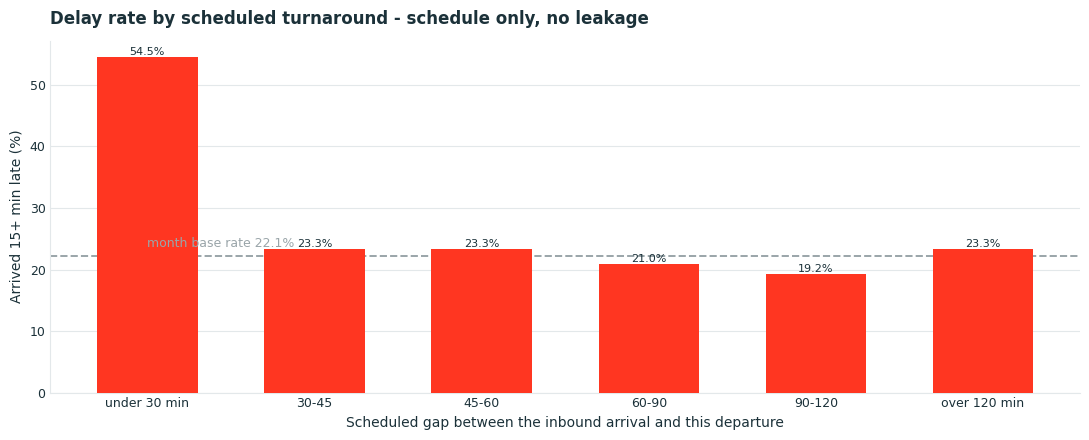

Tightest turns (under 30 min) : 54.47% delayed
Loosest turns  (over 120 min): 23.28% delayed
Spread: +31.19% (2.34x)

For scale, the strongest feature already in the model is hour of day, which
separates 8.5% at 05:00 from 28.1% at 19:00. A spread comparable to that
would make this worth the migration; one near zero would close the question.


In [0]:
BUCKETS = [(0, 30, "under 30 min"), (30, 45, "30-45"), (45, 60, "45-60"),
           (60, 90, "60-90"), (90, 120, "90-120"), (120, 100000, "over 120 min")]

bucket_col = F.lit("over 120 min")
for lo, hi, label in reversed(BUCKETS[:-1]):
    bucket_col = F.when((F.col("turnaround_min") >= lo) & (F.col("turnaround_min") < hi),
                        F.lit(label)).otherwise(bucket_col)

by_turn = (
    turnaround
    .filter((F.col("turnaround_min") >= 0) & (F.col("turnaround_min") <= 720))
    .withColumn("bucket", bucket_col)
    .groupBy("bucket")
    .agg(F.count("*").alias("flights"),
         F.avg("delayed").alias("delay_rate"),
         F.avg("arr_delay").alias("mean_arr_delay"))
    .toPandas()
)

order = [b[2] for b in BUCKETS]
by_turn["_o"] = by_turn["bucket"].apply(order.index)
by_turn = by_turn.sort_values("_o").drop(columns="_o").reset_index(drop=True)
display(by_turn)

fig, ax = P.new_axes(P.FIGSIZE_WIDE)
bars = ax.bar(by_turn["bucket"], by_turn["delay_rate"] * 100, color=P.ACCENT, zorder=3,
              width=0.6)
P.annotate_bars(ax, bars, [f"{v:.1%}" for v in by_turn["delay_rate"]])
ax.axhline(base_rate * 100, color=P.MUTED, linestyle="--", linewidth=1.4)
ax.annotate(f"month base rate {base_rate:.1%}", xy=(0, base_rate * 100),
            xytext=(0, base_rate * 100 + 1.5), fontsize=9, color=P.MUTED)
P.style(ax, title="Delay rate by scheduled turnaround - schedule only, no leakage",
        xlabel="Scheduled gap between the inbound arrival and this departure",
        ylabel="Arrived 15+ min late (%)")
plt.tight_layout(); plt.show()

tight = float(by_turn.iloc[0]["delay_rate"])
loose = float(by_turn.iloc[-1]["delay_rate"])
spread = tight - loose
print(f"Tightest turns ({by_turn.iloc[0]['bucket']}) : {tight:.2%} delayed")
print(f"Loosest turns  ({by_turn.iloc[-1]['bucket']}): {loose:.2%} delayed")
print(f"Spread: {spread:+.2%} ({tight / loose:.2f}x)")
print()
print("For scale, the strongest feature already in the model is hour of day, which")
print("separates 8.5% at 05:00 from 28.1% at 19:00. A spread comparable to that")
print("would make this worth the migration; one near zero would close the question.")

### Is that just hour of day wearing a different hat?

A 31-point spread is large enough that the first question has to be whether it is really a
new signal. Tight turns are not handed out at random: airlines schedule them at hubs, on
short-haul routes, and inside the afternoon and evening banks -- and hour of day is already
the strongest feature in the model, separating 8.5% at 05:00 from 28.1% at 19:00.

If the turnaround effect is hour of day in disguise, it disappears once hour is held fixed.
If tight turns are still worse *within* each departure hour, then it is carrying information
the model does not currently have, and the migration is worth costing properly.

This is a conditional comparison, not a controlled one -- it holds one confound fixed, not
all of them. Distance, carrier and airport are still free to vary. What it can rule out is
the single most likely alternative explanation, which is the one worth ruling out first.

dep_hour,tight_rate,tight_n,loose_rate,loose_n,gap_pp
6,0.10294117647058823,68,0.19642857142857142,56,-9.34873949579832
7,0.14318706697459585,866,0.21311475409836064,183,-6.9927687123764795
8,0.15577299412915852,2555,0.15463917525773196,873,0.11338188714265507
9,0.16801493466085873,3214,0.18150851581508515,2055,-1.3493581154226413
10,0.1812970261554998,5582,0.18354190367842246,2637,-0.22448775229226559
11,0.19983235540653813,5965,0.200352009386917,3409,-0.05196539803788702
12,0.22115895800106328,5643,0.18842676311030743,2765,3.273219489075585
13,0.25327102803738316,5350,0.21476063829787234,3008,3.851038973951082
14,0.2606281450633351,5763,0.20695807314897413,3363,5.367007191436096
15,0.27191060473269063,4564,0.20565371024734982,4245,6.6256894485340805


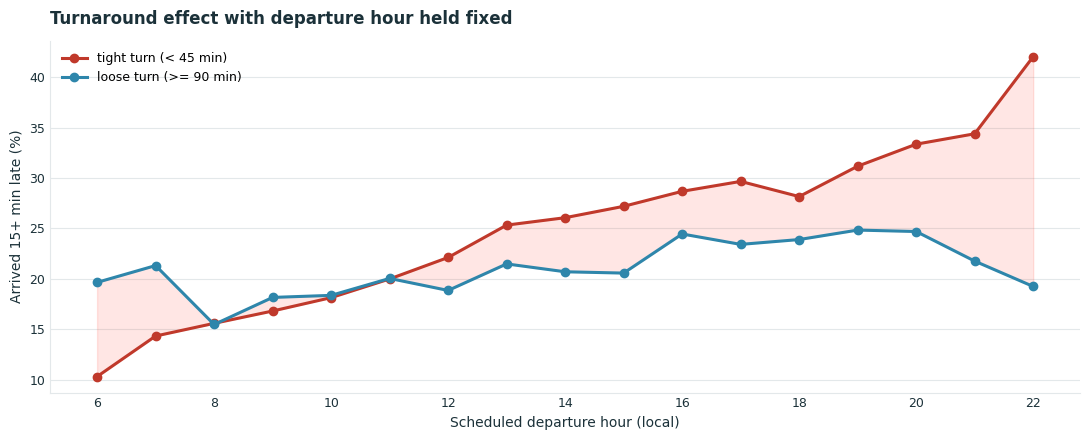

Hours where the tight-turn rate is higher: 12 of 17
Gap within an hour: min -9.3pp, median +4.2pp, max +22.8pp

The separation largely disappears once hour is held fixed, which means the
headline spread was substantially hour of day in disguise. That is a result:
it closes the question far more cheaply than a migration would have.


In [0]:
TIGHT_MAX, LOOSE_MIN = 45, 90

conditioned = (
    turnaround
    .filter((F.col("turnaround_min") >= 0) & (F.col("turnaround_min") <= 720))
    .withColumn("dep_hour", F.floor(F.col("crs_dep") / 100).cast("int"))
    .withColumn("turn_class",
                F.when(F.col("turnaround_min") < TIGHT_MAX, F.lit("tight"))
                 .when(F.col("turnaround_min") >= LOOSE_MIN, F.lit("loose")))
    .filter(F.col("turn_class").isNotNull())
    .filter(F.col("dep_hour").between(6, 22))
    .groupBy("dep_hour", "turn_class")
    .agg(F.count("*").alias("flights"), F.avg("delayed").alias("delay_rate"))
)

wide = (
    conditioned.groupBy("dep_hour")
    .pivot("turn_class", ["tight", "loose"])
    .agg(F.first("delay_rate"), F.first("flights"))
    .orderBy("dep_hour").toPandas()
)
wide.columns = ["dep_hour", "tight_rate", "tight_n", "loose_rate", "loose_n"]
wide = wide.dropna()
wide["gap_pp"] = (wide["tight_rate"] - wide["loose_rate"]) * 100
display(wide)

fig, ax = P.new_axes(P.FIGSIZE_WIDE)
ax.plot(wide["dep_hour"], wide["tight_rate"] * 100, color=P.POSITIVE, marker="o",
        markersize=6, linewidth=2.2, label=f"tight turn (< {TIGHT_MAX} min)")
ax.plot(wide["dep_hour"], wide["loose_rate"] * 100, color=P.NEGATIVE, marker="o",
        markersize=6, linewidth=2.2, label=f"loose turn (>= {LOOSE_MIN} min)")
ax.fill_between(wide["dep_hour"], wide["tight_rate"] * 100, wide["loose_rate"] * 100,
                color=P.ACCENT, alpha=0.12)
ax.legend(frameon=False, fontsize=9)
P.style(ax, title="Turnaround effect with departure hour held fixed",
        xlabel="Scheduled departure hour (local)", ylabel="Arrived 15+ min late (%)")
plt.tight_layout(); plt.show()

hours_tight_worse = int((wide["gap_pp"] > 0).sum())
print(f"Hours where the tight-turn rate is higher: {hours_tight_worse} of {len(wide)}")
print(f"Gap within an hour: min {wide['gap_pp'].min():+.1f}pp, "
      f"median {wide['gap_pp'].median():+.1f}pp, max {wide['gap_pp'].max():+.1f}pp")
print()
if hours_tight_worse == len(wide) and wide["gap_pp"].median() > 5:
    print("The separation survives conditioning on departure hour, in every hour of the")
    print("day. Turnaround is not hour of day under another name -- it carries something")
    print("the model has no access to, because the column it derives from is not in the")
    print("extract the model trains on.")
elif hours_tight_worse >= len(wide) * 0.8:
    print("The separation mostly survives, but not in every hour. Worth reporting with")
    print("the exceptions named rather than as a clean result.")
else:
    print("The separation largely disappears once hour is held fixed, which means the")
    print("headline spread was substantially hour of day in disguise. That is a result:")
    print("it closes the question far more cheaply than a migration would have.")

## 3. Was the carrier-level proxy any good?

Gold carries `dep_sequence_in_day`: the flight's ordinal among *that carrier's* departures
from that airport that day. It exists because the real quantity - how many legs this
**airframe** has already flown - needs a tail number.

If the two separate delay rates about equally, the proxy was doing the job and the tail number
buys less than it appears to. If the real ordinal separates much harder, the proxy was
standing in for something it could not see.

leg_number,flights,delay_rate,mean_arr_delay
2,122734,0.20859745465804097,5.557824237782522
3,103182,0.2306603865015216,7.384204609331085
4,80092,0.2495255456225341,8.938707985816311
5,45489,0.25186308777946315,8.908175602893007
6,24924,0.2515246348900658,9.495867437008506
7,6393,0.2662286876270921,10.215704676990459
8,2319,0.2613195342820181,10.704182837429927


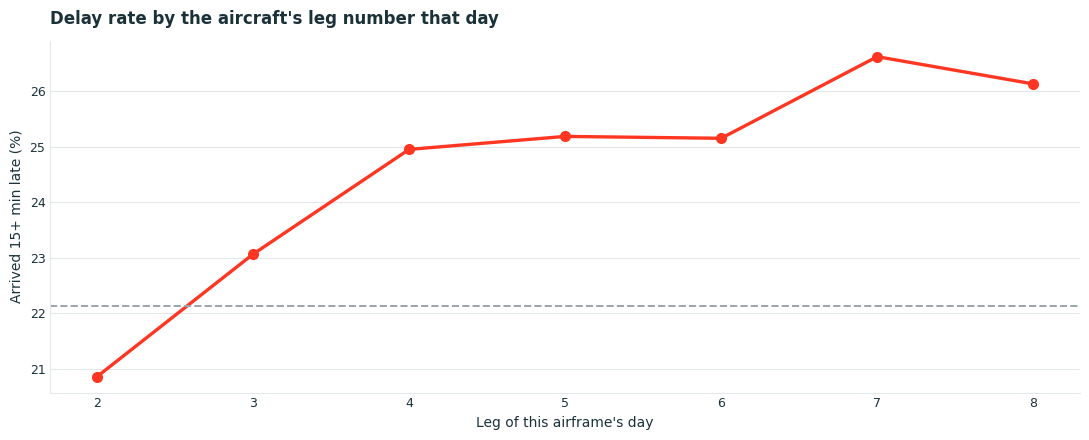

Leg 1: 20.86% delayed     leg 8: 26.13%
Spread across the aircraft's day: +5.27%

This is the cascade 02_eda measured from the other direction, where the
late-aircraft share of delay minutes climbed from 15.2% before 09:00 to
44.4% after 18:00. Same phenomenon, counted per airframe rather than per hour.


In [0]:
by_leg = (
    chained
    .filter(F.col("leg_number") <= 8)
    .groupBy("leg_number")
    .agg(F.count("*").alias("flights"),
         F.avg("delayed").alias("delay_rate"),
         F.avg("arr_delay").alias("mean_arr_delay"))
    .orderBy("leg_number").toPandas()
)
display(by_leg)

fig, ax = P.new_axes(P.FIGSIZE_WIDE)
ax.plot(by_leg["leg_number"], by_leg["delay_rate"] * 100, color=P.ACCENT,
        marker="o", markersize=7, linewidth=2.4)
ax.axhline(base_rate * 100, color=P.MUTED, linestyle="--", linewidth=1.4)
P.style(ax, title="Delay rate by the aircraft's leg number that day",
        xlabel="Leg of this airframe's day", ylabel="Arrived 15+ min late (%)")
plt.tight_layout(); plt.show()

first = float(by_leg.iloc[0]["delay_rate"])
last = float(by_leg.iloc[-1]["delay_rate"])
print(f"Leg 1: {first:.2%} delayed     leg {int(by_leg.iloc[-1]['leg_number'])}: {last:.2%}")
print(f"Spread across the aircraft's day: {last - first:+.2%}")
print()
print("This is the cascade 02_eda measured from the other direction, where the")
print("late-aircraft share of delay minutes climbed from 15.2% before 09:00 to")
print("44.4% after 18:00. Same phenomenon, counted per airframe rather than per hour.")

## 4. What the 10% sample did to the congestion counts

`sched_deps_origin_hour` counts the flights scheduled out of an airport in the same hour. On
the sample it had a mean of 3.3, which is why Gold uses `origin_hour_share` instead - a ratio
survives uniform sampling and a count does not.

This is the same statistic on the full population, and the ratio between them is the size of
the distortion the share features were built to route around.

In [0]:
congestion = (
    flights
    .withColumn("dep_hour", F.floor(F.col("crs_dep") / 100))
    .groupBy("origin", "flight_date", "dep_hour")
    .agg(F.count("*").alias("departures_in_hour"))
)

stats = congestion.agg(
    F.avg("departures_in_hour").alias("mean"),
    F.expr("percentile_approx(departures_in_hour, 0.5)").alias("median"),
    F.max("departures_in_hour").alias("max"),
).first()

SAMPLE_MEAN = 3.3   # recorded in the README from the ~10% extract

print("Departures per origin-hour, full population:")
print(f"  mean {stats['mean']:.1f}   median {stats['median']:.0f}   max {stats['max']:,}")
print(f"  the same statistic on the ~10% sample: {SAMPLE_MEAN}")
print()
print("The means are closer than a tenfold sample would suggest, and the median of")
print(f"{stats['median']:.0f} says why: most origin-hours belong to small airports with one or")
print("two departures, and they dominate an unweighted mean on either dataset. The")
print("global mean was the wrong statistic to quote. The claim the share features")
print("were built on is about *hubs*, so the comparison has to be made there.")

# At a hub the distortion is visible, because a hub is where the count is large
# enough for a tenth of it to be a different number rather than the same small one.
HUBS = ["ATL", "ORD", "DFW", "DEN", "CLT"]
by_hub = (
    congestion.filter(F.col("origin").isin(HUBS))
    .groupBy("origin")
    .agg(F.avg("departures_in_hour").alias("mean_per_hour"),
         F.expr("percentile_approx(departures_in_hour, 0.9)").alias("p90"),
         F.max("departures_in_hour").alias("busiest_hour"))
    .orderBy(F.desc("busiest_hour")).toPandas()
)
display(by_hub)

peak = float(by_hub["busiest_hour"].max())
print(f"Busiest single origin-hour across these hubs: {peak:.0f} departures.")
print(f"A ~10% sample of that hour shows about {peak / 10:.0f}.")
print()
print("That is the distortion the share features exist to avoid, now measured at the")
print("airports the claim was about rather than averaged across every airfield in the")
print("country. On full data the raw counts become usable, and whether they beat the")
print("shares stops being a constraint and becomes a question with an answer.")

Departures per origin-hour, full population:
  mean 6.5   median 2   max 84
  the same statistic on the ~10% sample: 3.3

The means are closer than a tenfold sample would suggest, and the median of
2 says why: most origin-hours belong to small airports with one or
two departures, and they dominate an unweighted mean on either dataset. The
global mean was the wrong statistic to quote. The claim the share features
were built on is about *hubs*, so the comparison has to be made there.


origin,mean_per_hour,p90,busiest_hour
ORD,35.65342960288809,69,84
DEN,34.85322580645161,67,84
DFW,34.05190311418685,63,79
ATL,44.61460101867572,66,76
CLT,26.669642857142858,56,62


Busiest single origin-hour across these hubs: 84 departures.
A ~10% sample of that hour shows about 8.

That is the distortion the share features exist to avoid, now measured at the
airports the claim was about rather than averaged across every airfield in the
country. On full data the raw counts become usable, and whether they beat the
shares stops being a constraint and becomes a question with an answer.


## What this probe decided

| | |
|---|---|
| **Sample** | One month, full population. Not a model result and not a substitute for one |
| **Caveat** | January. Winter weather inflates the base rate against an annual average, and the *relative* separation between buckets is the transferable part, not the levels |
| **Caveat** | Chains break at midnight and at the month boundary. A leg whose inbound flew yesterday is counted as leg 1 |
| **Not measured** | What any of this is worth in ROC-AUC. That needs the migration, and the point of the probe is to decide whether to pay for it |

Both rotation features here are **schedule-only**: knowable days ahead, no leakage, and
legitimate inputs to the pre-departure model. The inbound aircraft's *actual* arrival delay is
deliberately not among them - it is the stronger signal and it is not available before
departure, so training on it would be train/serve skew rather than a feature.